In [41]:
import pandas as pd
import scipy.constants as const

In [42]:
df = pd.read_csv("Stopping Voltages 400.csv")

In [43]:
df.drop(columns=["filter"], inplace=True)

In [44]:
df["-e_delta_v"] = -const.e * (-df["stopping_voltage"])
df["c_over_lambda"] = const.c / (df["wavelength"] * 1e-9)

In [45]:
df.head()

,wavelength,initial_current,stopping_voltage,stopping_voltage_uncertainty,-e_delta_v,c_over_lambda
0,640,5.21,0.3113,0.0001,4.987576e-20,4.684257e+14
1,626,5.21,0.4073,0.0001,6.525665e-20,4.789017e+14
2,604,5.21,0.4929,0.0001,7.897129e-20,4.963451e+14
3,590,5.21,0.5669,0.0001,9.082739e-20,5.081228e+14
4,570,5.21,0.6306,0.0001,1.010333e-19,5.259517e+14


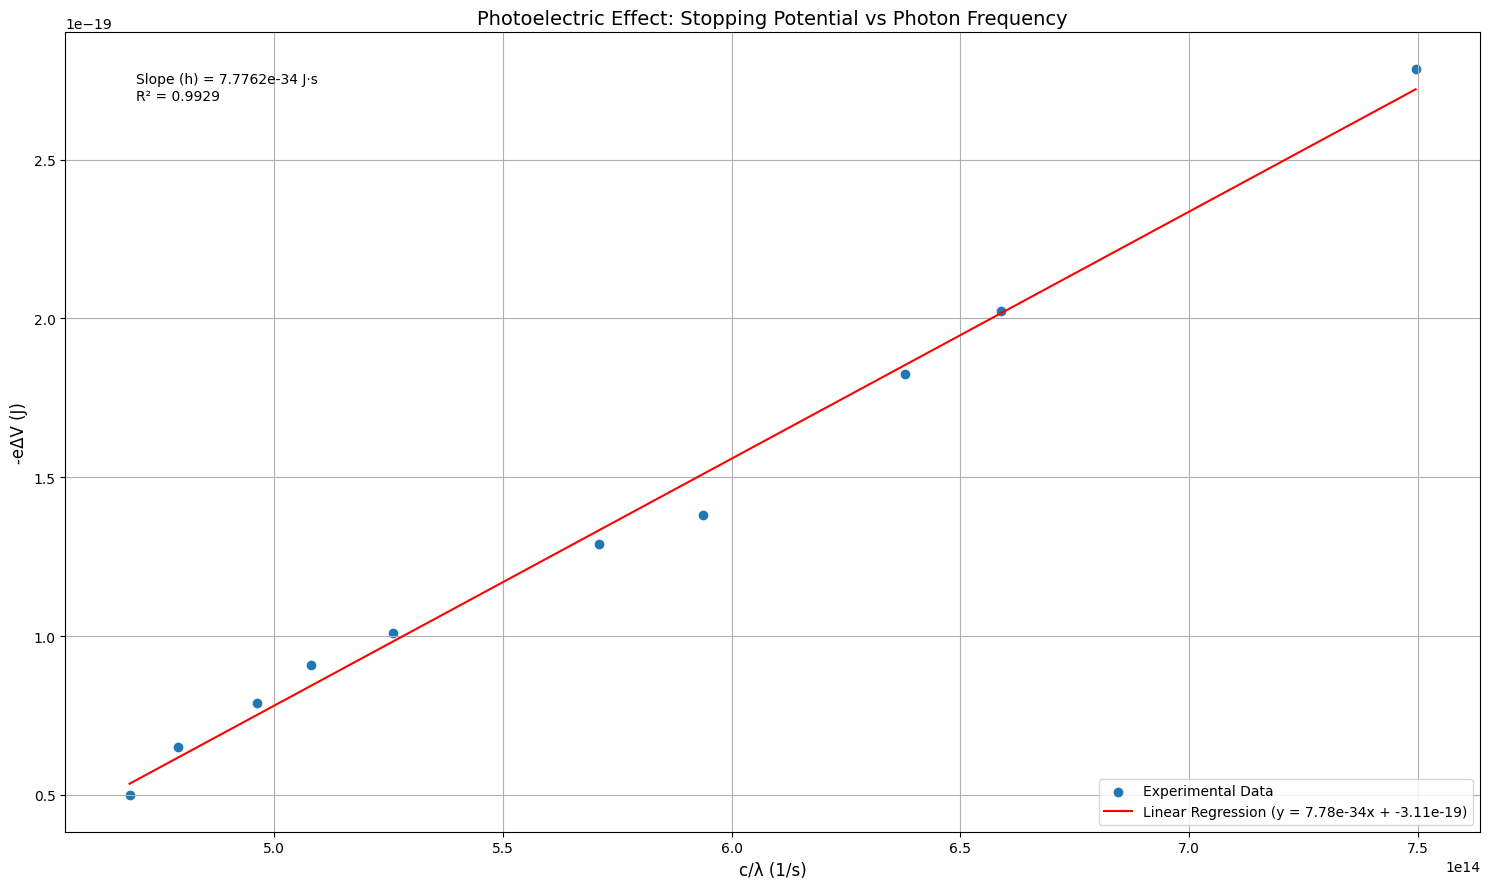

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.figure(figsize=(15, 9))
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["c_over_lambda"], df["-e_delta_v"]
)

plt.scatter(df["c_over_lambda"], df["-e_delta_v"], label="Experimental Data")
plt.plot(
    df["c_over_lambda"],
    intercept + slope * df["c_over_lambda"],
    "r",
    label=f"Linear Regression (y = {slope:.2e}x + {intercept:.2e})",
)

plt.xlabel("c/λ (1/s)", fontsize=12)
plt.ylabel("-eΔV (J)", fontsize=12)
plt.title("Photoelectric Effect: Stopping Potential vs Photon Frequency", fontsize=14)
plt.legend()
plt.grid(True)

plt.text(
    0.05,
    0.95,
    f"Slope (h) = {slope:.4e} J·s\nR² = {r_value**2:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.tight_layout()
plt.show()


In [47]:
old_df = pd.read_csv("voltages.csv")
old_df.columns

Index(['index', 'stopping_voltage', 'voltage_unc', 'wavelength',
       'filter_wavelength'],
      dtype='object')

In [48]:
old_df["-e_delta_v"] = -const.e * (old_df["stopping_voltage"] * 1e-3)
old_df["c_over_lambda"] = const.c / (old_df["wavelength"] * 1e-9)

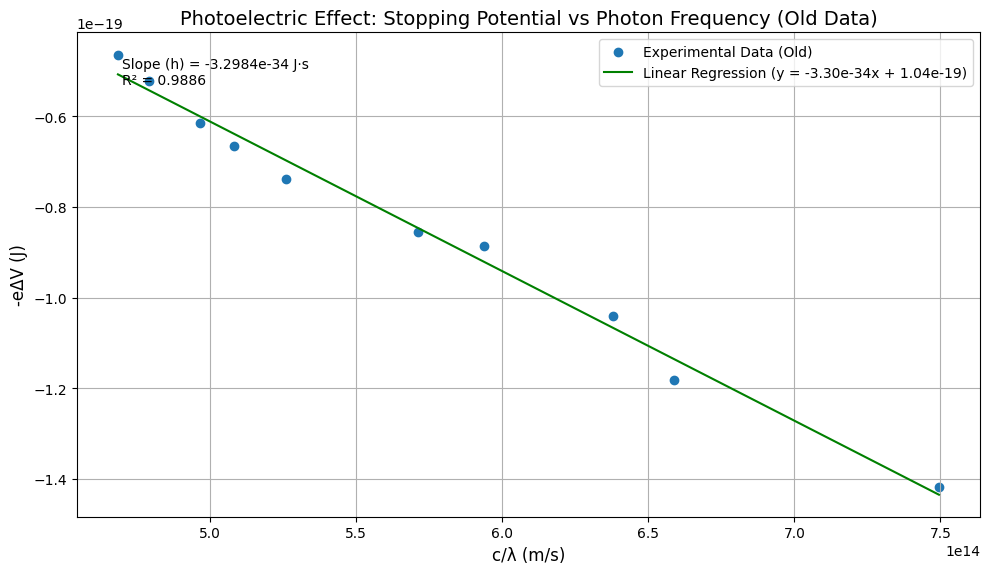

In [49]:
plt.figure(figsize=(10, 6))
slope_old, intercept_old, r_value_old, p_value_old, std_err_old = stats.linregress(
    old_df["c_over_lambda"], old_df["-e_delta_v"]
)

plt.scatter(
    old_df["c_over_lambda"], old_df["-e_delta_v"], label="Experimental Data (Old)"
)
plt.plot(
    old_df["c_over_lambda"],
    intercept_old + slope_old * old_df["c_over_lambda"],
    "g",
    label=f"Linear Regression (y = {slope_old:.2e}x + {intercept_old:.2e})",
)

plt.xlabel("c/λ (m/s)", fontsize=12)
plt.ylabel("-eΔV (J)", fontsize=12)
plt.title(
    "Photoelectric Effect: Stopping Potential vs Photon Frequency (Old Data)",
    fontsize=14,
)
plt.legend()
plt.grid(True)

plt.text(
    0.05,
    0.95,
    f"Slope (h) = {slope_old:.4e} J·s\nR² = {r_value_old**2:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.tight_layout()
plt.show()
